🔄 Loading Raw Data...


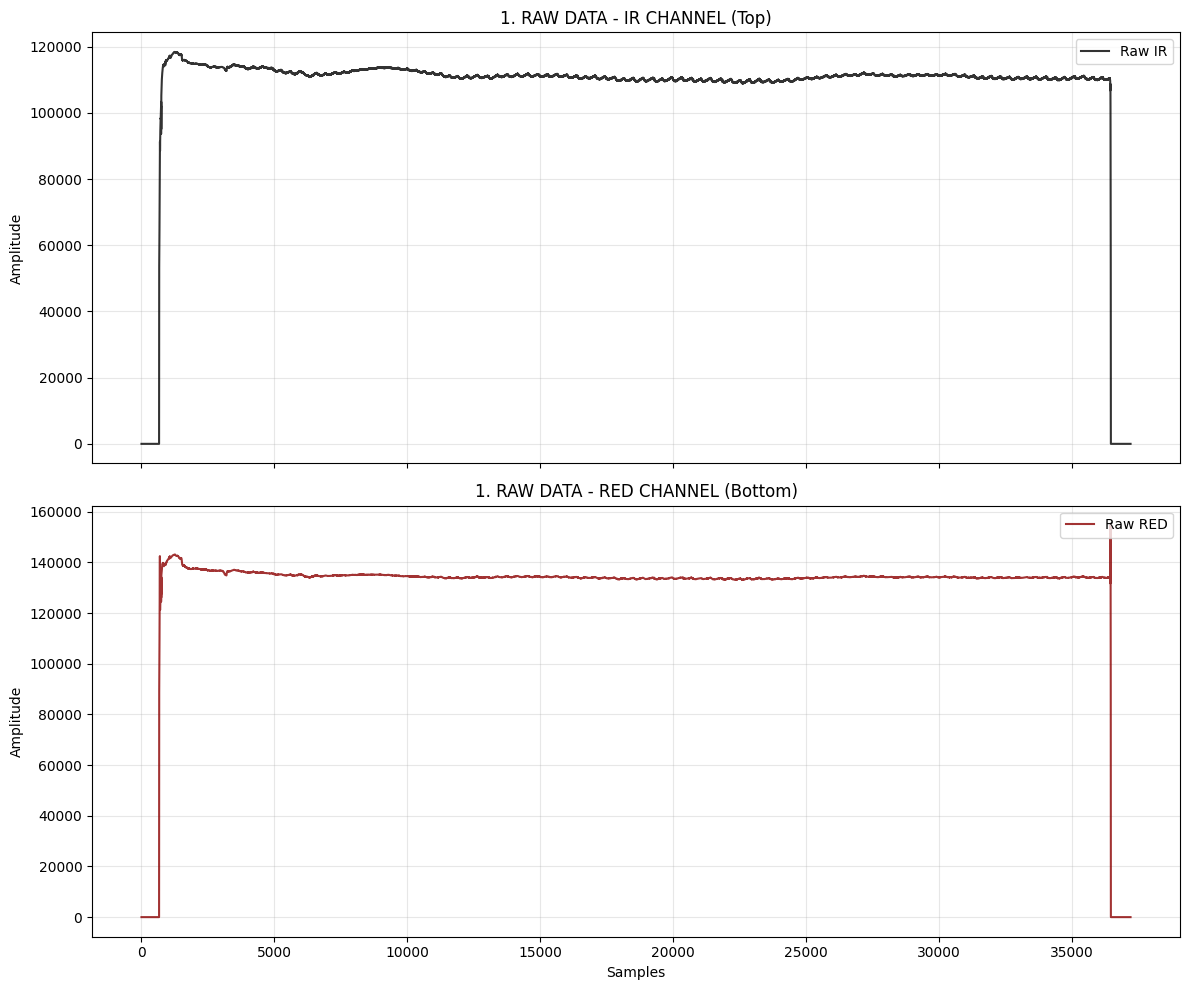

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 🔧 CONFIGURATION
# ==========================================
FILENAME = '../Python_tools/ppg_data_B0001_rms01_0001_T21.csv'   

# ==========================================
# ⚙️ EXECUTION
# ==========================================
print("🔄 Loading Raw Data...")
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()
rename_map = {'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 'RED VALUE': 'RED', 'IR VALUE': 'IR'}
df = df.rename(columns=rename_map)

# ==========================================
# 📊 PLOT 1: RAW CSV (IR Top, RED Bottom)
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 1. IR (Top)
ax1.plot(df['IR'].values, color='black', label='Raw IR', alpha=0.8)
ax1.set_title('1. RAW DATA - IR CHANNEL (Top)')
ax1.set_ylabel('Amplitude')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. RED (Bottom)
ax2.plot(df['RED'].values, color='darkred', label='Raw RED', alpha=0.8)
ax2.set_title('1. RAW DATA - RED CHANNEL (Bottom)')
ax2.set_ylabel('Amplitude')
ax2.set_xlabel('Samples')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

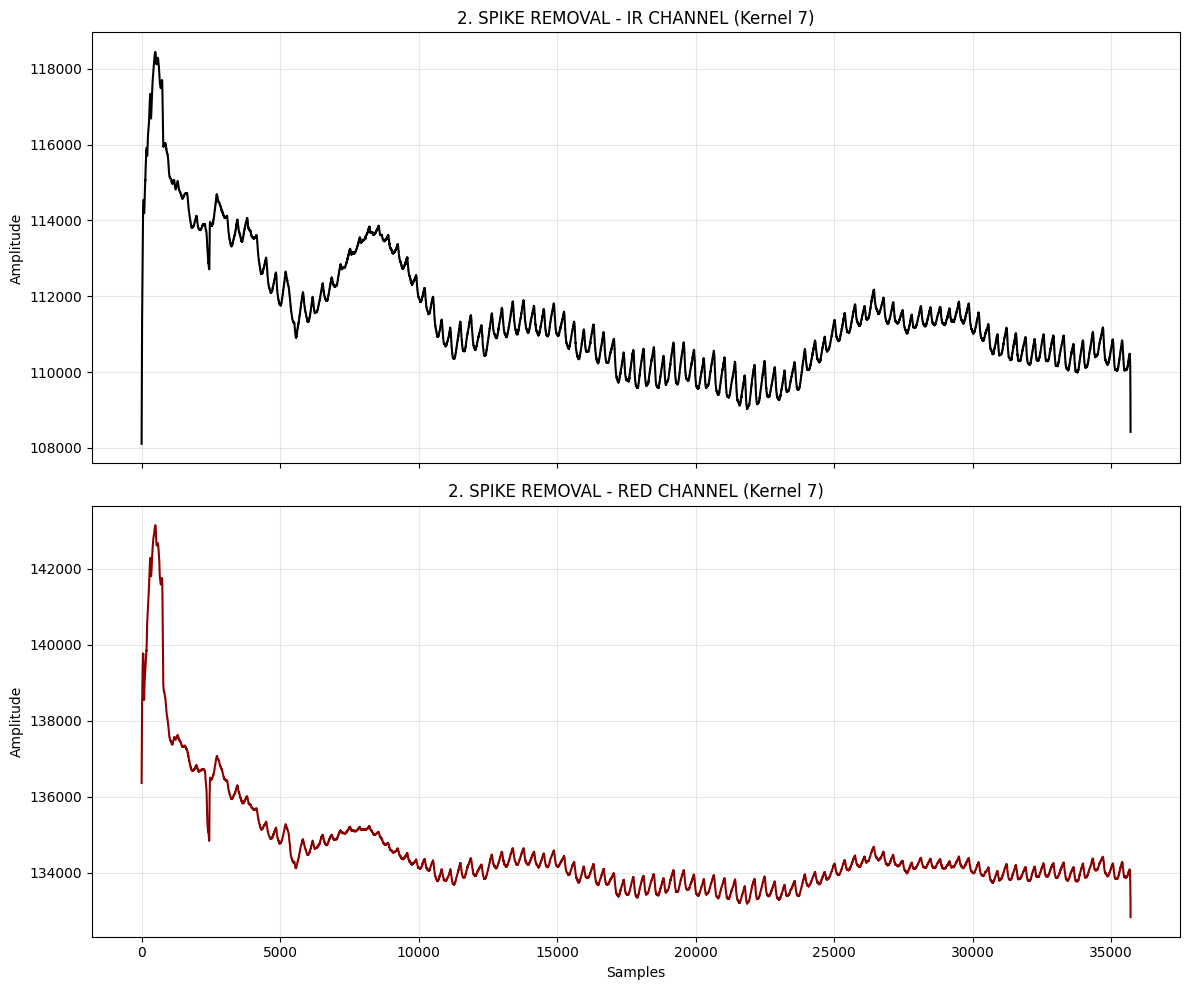

In [2]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt

# ==========================================
# 🔧 CONFIGURATION
# ==========================================
FILENAME = '../Python_tools/ppg_data_B0001_rms01_0001_T21.csv'   
KERNEL_SIZE = 7             # Spike Removal Strength (Odd Number)
THRESHOLD_RED = 132000      # Valid Signal Limit
THRESHOLD_IR = 108000       # Valid Signal Limit

# ==========================================
# ⚙️ EXECUTION
# ==========================================
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()
df = df.rename(columns={'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 'RED VALUE': 'RED', 'IR VALUE': 'IR'})

# Apply Thresholds
mask = (df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)
clean_df = df[mask].copy()

# Apply Median Filter (Spike Removal)
ir_despiked  = signal.medfilt(clean_df['IR'].values, kernel_size=KERNEL_SIZE)
red_despiked = signal.medfilt(clean_df['RED'].values, kernel_size=KERNEL_SIZE)

# ==========================================
# 📊 PLOT 2: SPIKE REMOVAL (IR Top, RED Bottom)
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 1. IR Despiked (Top)
ax1.plot(ir_despiked, color='black', label='IR Despiked')
ax1.set_title(f'2. SPIKE REMOVAL - IR CHANNEL (Kernel {KERNEL_SIZE})')
ax1.set_ylabel('Amplitude')
ax1.grid(True, alpha=0.3)

# 2. RED Despiked (Bottom)
ax2.plot(red_despiked, color='darkred', label='RED Despiked')
ax2.set_title(f'2. SPIKE REMOVAL - RED CHANNEL (Kernel {KERNEL_SIZE})')
ax2.set_ylabel('Amplitude')
ax2.set_xlabel('Samples')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

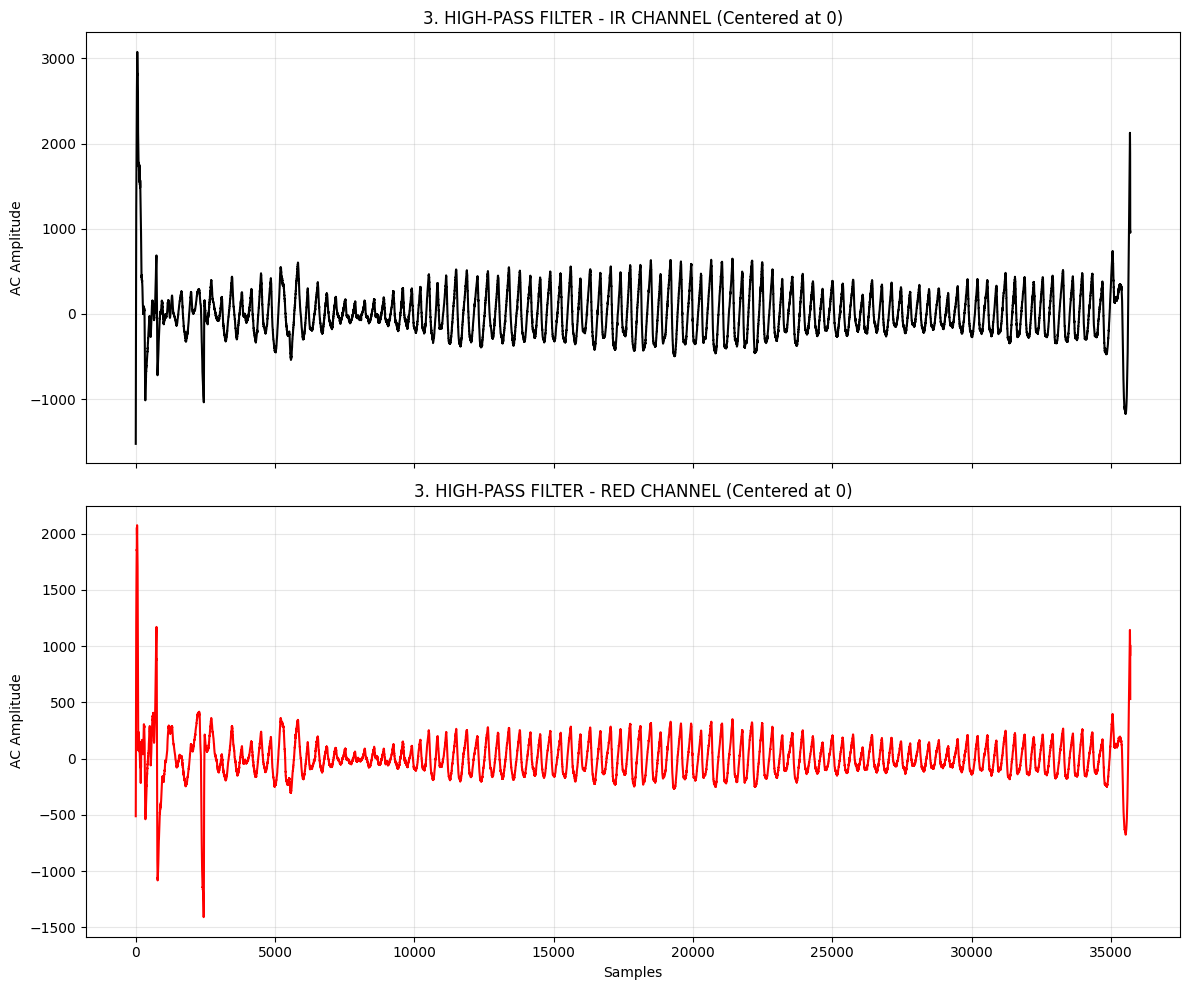

In [3]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt

# ==========================================
# 🔧 CONFIGURATION
# ==========================================
FILENAME = '../Python_tools/ppg_data_B0001_rms01_0001_T21.csv'   
FS = 400.0
HP_CUTOFF = 0.5             # Removes Breathing/Drift
HP_ORDER = 4
KERNEL_SIZE = 7; THRESHOLD_RED = 132000; THRESHOLD_IR = 108000

# ==========================================
# ⚙️ EXECUTION
# ==========================================
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()
df = df.rename(columns={'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 'RED VALUE': 'RED', 'IR VALUE': 'IR'})
clean_df = df[(df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)].copy()

# 1. Despike
ir_despiked  = signal.medfilt(clean_df['IR'].values, kernel_size=KERNEL_SIZE)
red_despiked = signal.medfilt(clean_df['RED'].values, kernel_size=KERNEL_SIZE)

# 2. High-Pass Filter
nyquist = 0.5 * FS
sos_hp = signal.butter(HP_ORDER, HP_CUTOFF / nyquist, btype='high', analog=False, output='sos')

ir_hp  = signal.sosfiltfilt(sos_hp, ir_despiked)
red_hp = signal.sosfiltfilt(sos_hp, red_despiked)

# ==========================================
# 📊 PLOT 3: HIGH-PASS OUTPUT (IR Top, RED Bottom)
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 1. IR High-Passed (Top)
ax1.plot(ir_hp, color='black', label='IR High-Pass')
ax1.set_title(f'3. HIGH-PASS FILTER - IR CHANNEL (Centered at 0)')
ax1.set_ylabel('AC Amplitude')
ax1.grid(True, alpha=0.3)

# 2. RED High-Passed (Bottom)
ax2.plot(red_hp, color='red', label='RED High-Pass')
ax2.set_title(f'3. HIGH-PASS FILTER - RED CHANNEL (Centered at 0)')
ax2.set_ylabel('AC Amplitude')
ax2.set_xlabel('Samples')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

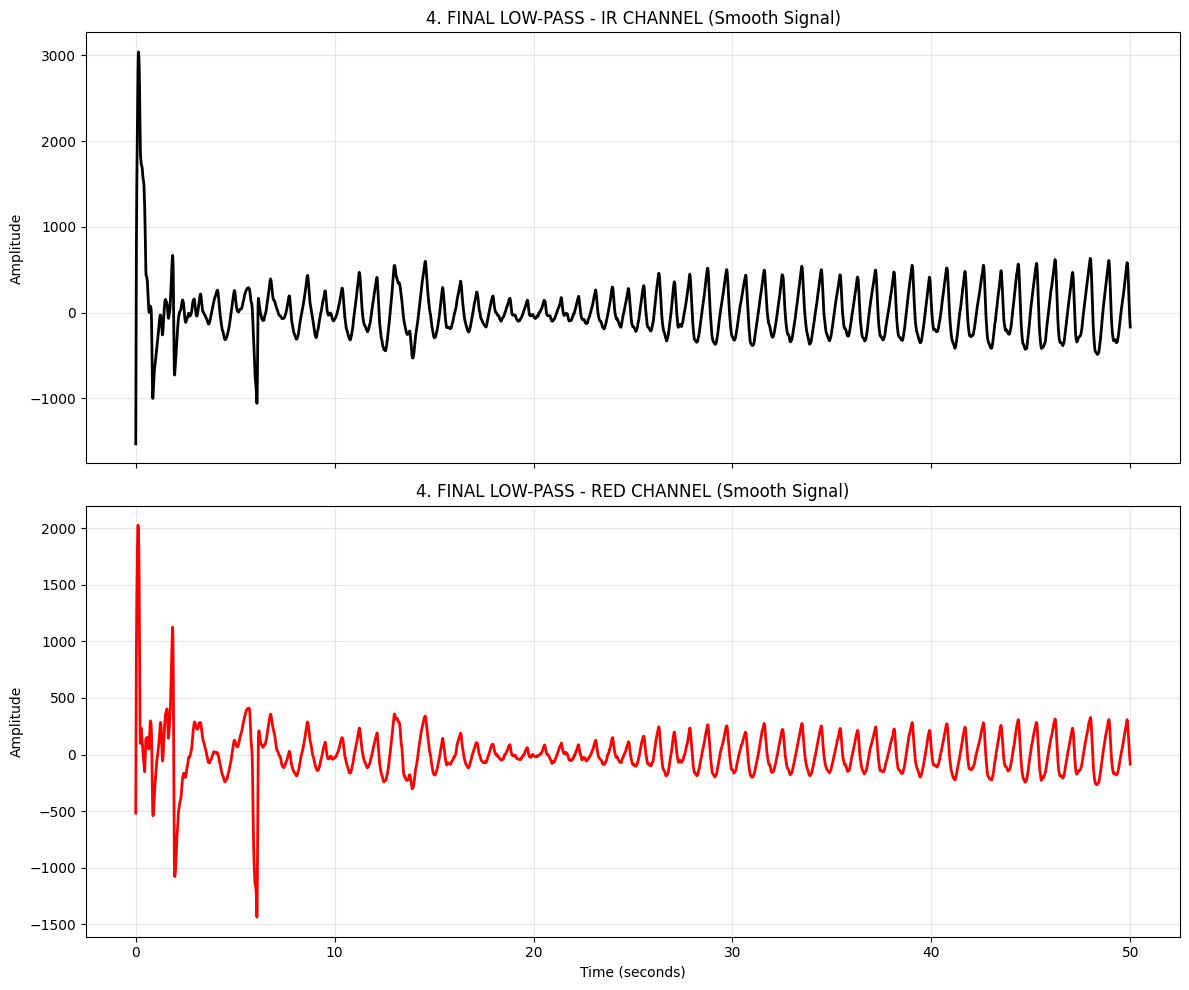

In [4]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt

# ==========================================
# 🔧 CONFIGURATION
# ==========================================
FILENAME = '../Python_tools/ppg_data_B0001_rms01_0001_T21.csv'   
FS = 400.0
LP_CUTOFF = 16.0            # Removes Jitter
LP_ORDER = 4
HP_CUTOFF = 0.5; HP_ORDER = 4; KERNEL_SIZE = 7; 
THRESHOLD_RED = 132000; THRESHOLD_IR = 108000

# ==========================================
# ⚙️ EXECUTION
# ==========================================
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()
df = df.rename(columns={'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 'RED VALUE': 'RED', 'IR VALUE': 'IR'})
clean_df = df[(df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)].copy()

# 1. Despike
ir_despiked  = signal.medfilt(clean_df['IR'].values, kernel_size=KERNEL_SIZE)
red_despiked = signal.medfilt(clean_df['RED'].values, kernel_size=KERNEL_SIZE)

# 2. High-Pass
nyquist = 0.5 * FS
sos_hp = signal.butter(HP_ORDER, HP_CUTOFF / nyquist, btype='high', analog=False, output='sos')
ir_hp  = signal.sosfiltfilt(sos_hp, ir_despiked)
red_hp = signal.sosfiltfilt(sos_hp, red_despiked)

# 3. Low-Pass Filter (Final Step)
sos_lp = signal.butter(LP_ORDER, LP_CUTOFF / nyquist, btype='low', analog=False, output='sos')
ir_clean  = signal.sosfiltfilt(sos_lp, ir_hp)
red_clean = signal.sosfiltfilt(sos_lp, red_hp)

# ==========================================
# 📊 PLOT 4: LOW-PASS OUTPUT (IR Top, RED Bottom)
# ==========================================
# Zoom in on first 800 samples (2 seconds) for clarity
LIMIT = 20000
t = np.arange(LIMIT) / FS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 1. IR Clean (Top)
ax1.plot(t, ir_clean[:LIMIT], color='black', linewidth=2, label='IR Clean')
ax1.set_title(f'4. FINAL LOW-PASS - IR CHANNEL (Smooth Signal)')
ax1.set_ylabel('Amplitude')
ax1.grid(True, alpha=0.3)

# 2. RED Clean (Bottom)
ax2.plot(t, red_clean[:LIMIT], color='red', linewidth=2, label='RED Clean')
ax2.set_title(f'4. FINAL LOW-PASS - RED CHANNEL (Smooth Signal)')
ax2.set_ylabel('Amplitude')
ax2.set_xlabel('Time (seconds)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.stats as stats

# ==========================================
# 🔧 TASK 4 CONFIGURATION (MANUAL)
# ==========================================
FILENAME = '../Python_tools/ppg_data_B0001_rms01_0001_T21.csv'   
FS = 400.0; LP_CUTOFF = 16.0; HP_CUTOFF = 0.5; KERNEL_SIZE = 7; 
THRESHOLD_RED = 132000; THRESHOLD_IR = 108000

# ==========================================
# ⚙️ PREPARATION (Re-running Pipeline)
# ==========================================
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()
df = df.rename(columns={'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 'RED VALUE': 'RED', 'IR VALUE': 'IR'})
clean_df = df[(df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)].copy()

# Pipeline: Despike -> HighPass -> LowPass
nyquist = 0.5 * FS
sos_hp = signal.butter(4, HP_CUTOFF / nyquist, btype='high', analog=False, output='sos')
sos_lp = signal.butter(4, LP_CUTOFF / nyquist, btype='low', analog=False, output='sos')

# Process RED
red_d = signal.medfilt(clean_df['RED'].values, kernel_size=KERNEL_SIZE)
red_h = signal.sosfiltfilt(sos_hp, red_d)
red_final = signal.sosfiltfilt(sos_lp, red_h)

# Process IR
ir_d = signal.medfilt(clean_df['IR'].values, kernel_size=KERNEL_SIZE)
ir_h = signal.sosfiltfilt(sos_hp, ir_d)
ir_final = signal.sosfiltfilt(sos_lp, ir_h)

# ==========================================
# 📝 ANALYSIS FUNCTION
# ==========================================
def print_quality_report(name, clean_ac, raw_dc):
    print(f"\n📊 REPORT: {name}")
    print("=" * 30)
    
    # 1. Shape Stats (Use Clean AC Signal)
    skew = stats.skew(clean_ac)
    kurt = stats.kurtosis(clean_ac)
    
    # 2. Perfusion Index (PI) = (AC / DC) * 100
    ac_amp = np.max(clean_ac) - np.min(clean_ac)
    dc_amp = np.mean(raw_dc)
    
    if dc_amp == 0: pi = 0
    else: pi = (ac_amp / dc_amp) * 100
    
    # 3. Verdict
    status = "✅ PASS"
    if skew < 0.2: status = "⚠️ WARNING (Signal flat/noisy)"
    if pi < 0.1:   status = "❌ FAIL (Weak signal)"
    
    print(f"  Skewness:        {skew:.4f}  (Target: > 0.2)")
    print(f"  Kurtosis:        {kurt:.4f}  (Target: > 0.0)")
    print(f"  Perfusion Index: {pi:.4f}%   (Target: > 0.1%)")
    print("-" * 30)
    print(f"  VERDICT:         {status}")

# ==========================================
# 🚀 EXECUTE REPORT
# ==========================================
print("\n🔎 RUNNING SIGNAL QUALITY ANALYSIS...")

# Report for RED
print_quality_report("RED CHANNEL", red_final, clean_df['RED'].values)

# Report for IR
print_quality_report("IR CHANNEL ", ir_final, clean_df['IR'].values)


🔎 RUNNING SIGNAL QUALITY ANALYSIS...

📊 REPORT: RED CHANNEL
  Skewness:        1.0276  (Target: > 0.2)
  Kurtosis:        21.5755  (Target: > 0.0)
  Perfusion Index: 2.5736%   (Target: > 0.1%)
------------------------------
  VERDICT:         ✅ PASS

📊 REPORT: IR CHANNEL 
  Skewness:        1.8293  (Target: > 0.2)
  Kurtosis:        14.4104  (Target: > 0.0)
  Perfusion Index: 4.1006%   (Target: > 0.1%)
------------------------------
  VERDICT:         ✅ PASS
